In [ ]:
### Notebook here runs a correlation between the number of condensates a c-mod perturbs and its properties, including:
### > Running filtering of c-mods
### > Correlating numbre of c-mods perturbed vs chemical properties (Fig 4 and Extended Data Fig 5)

In [1]:
import ast
import math
import pandas as pd
import numpy as np
import re
from rdkit import Chem, rdBase
import matplotlib.pyplot as plt
import seaborn as sns
import dataframe_image as dfi
from rdkit.Chem import Descriptors, rdMolDescriptors, MACCSkeys
from rdkit.Chem import FilterCatalog
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Draw import IPythonConsole
from umap import UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.utils import resample
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import StratifiedKFold
from scipy.stats import ks_2samp, mannwhitneyu
from scipy.stats import pearsonr, spearmanr
from scipy.stats import gaussian_kde

In [2]:
rdBase.DisableLog("rdApp.*")

In [3]:
sns.set_style("whitegrid")

In [4]:
#Load dataset of c-mods from d.paint 20 screen
cmods_df = pd.read_csv("./data/dpaint20_cmods.csv")
cmods_df["chemformer"] = cmods_df["chemformer"].apply(ast.literal_eval)
cmods_df["Set"] = "C-mod"

In [5]:
#Load info on number of condensates perturbed by each c-mod
cmods_df_num_perturbed = pd.read_excel(
    "./data/dpaint20_cmpds_and_cmods.xlsx",
    sheet_name="Top-5_cond_count",
)

In [6]:
#Join together
cmods_df = cmods_df.merge(
    cmods_df_num_perturbed[["compound_id", "condensate_count"]],
    on="compound_id",
    how="left",
)

In [7]:
#Check whether any c-mods have <1 condensate perturbed
n_null = cmods_df["condensate_count"].isna().sum()
print(f"Null condensate_count values in cmods_df: {n_null}")

Null condensate_count values in cmods_df: 0


In [8]:
#Function to calculate chemical descriptors

def calc_mol_desc(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    def safe_div(num, denom):
        return float(num) / float(denom) if denom else 0.0
    
    num_heavy_atoms = Descriptors.HeavyAtomCount(mol)
    num_aromatic_atoms = sum(atom.GetIsAromatic() for atom in mol.GetAtoms())
    num_ring_atoms = sum(atom.IsInRing() for atom in mol.GetAtoms())
    valence_e = Descriptors.NumValenceElectrons(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    num_rotatable_bonds = Descriptors.NumRotatableBonds(mol)
    
    return {
        "QED": Descriptors.qed(mol),
        "LogP": Descriptors.MolLogP(mol),
        "MW": Descriptors.ExactMolWt(mol),
        "# of valence electrons": Descriptors.NumValenceElectrons(mol),
        "# of rings": Descriptors.RingCount(mol),
#        "# of heavy atoms": Descriptors.HeavyAtomCount(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "# of rotatable bonds": num_rotatable_bonds,
        "TPSA": Descriptors.TPSA(mol),
        "# of aromatic rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "ratio rotatable bonds to atoms": safe_div(num_rotatable_bonds,num_heavy_atoms),
        "fraction atoms in aromatic rings": safe_div(num_aromatic_atoms,num_heavy_atoms), 
        "fraction atoms in rings": safe_div(num_ring_atoms,num_heavy_atoms),
        "ratio valence electrons to atoms": safe_div(valence_e,num_heavy_atoms),
        "fraction HBD": safe_div(hbd,num_heavy_atoms),
        "fraction HBA": safe_div(hba,num_heavy_atoms),
    }

In [9]:
#Calculate chemical descriptors for c-mods
mol_desc = cmods_df["canon_smiles"].apply(calc_mol_desc)
mol_desc = mol_desc.apply(pd.Series)
desc_cols = mol_desc.columns
cmods_df = cmods_df.join(mol_desc)

In [10]:
#Function to build PAINS catalog for filtering
def build_pains_catalog():
    pains_params = FilterCatalog.FilterCatalogParams()
    pains_sets = [
        FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_A,
        FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_B,
#        FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_C, << Only use High (A) and Medium (B) filters for now
    ]
    for p in pains_sets:
        pains_params.AddCatalog(p)
    return FilterCatalog.FilterCatalog(pains_params)

pains_catalog = build_pains_catalog()

In [11]:
#Function to remove any null smiles
def smiles_to_mol(smiles):
    if pd.isna(smiles):
        return None
    return Chem.MolFromSmiles(smiles)

In [12]:
#Function to run PAINS filtering using catalog generated
def is_pains(mol):
    return pains_catalog.HasMatch(mol)

In [13]:
#Apply to c-mods
cmods_df["rdkit_mol"] = cmods_df["SMILES"].apply(smiles_to_mol)

cmods_df["is_pains"] = cmods_df["rdkit_mol"].apply(is_pains)

cmods_filtered_df = cmods_df[~cmods_df["is_pains"]].copy()

In [14]:
#Remove any c-mods >1000Da
cmods_filtered_df = cmods_filtered_df[cmods_filtered_df["MW"] < 1000]

In [15]:
#Check number of compounds in each set, before and after filtering

pd.DataFrame(
    {
        "C-mod": [len(cmods_df)],
        "Filtered c-mod": [len(cmods_filtered_df)],
    },
    index=["Number of compounds"],
).style.set_table_styles(
    [
        {"selector": "td", "props": [("border", "1px solid black")]},
        {"selector": "th", "props": [("border", "1px solid black")]},
        {"selector": "th.col_heading", "props": [("background-color", "lightgray")]},
        {"selector": "th.row_heading", "props": [("background-color", "lightgray")]},
        {"selector": "caption", "props": [("font-weight", "bold")]},
    ],
).format(
    "{:,}"
)

,C-mod,Filtered c-mod
Number of compounds,587,512


In [16]:
#Calculate Spearman and Pearson correlations for each chemical descriptor, and check significance (including multiple comparison correction)
df = cmods_filtered_df
xcol = "condensate_count"
desc_cols = [
    "QED",
    "LogP",
    "MW",
    "# of valence electrons",
    "# of rings",
    "HBD",
    "HBA",
    "# of rotatable bonds",
    "TPSA",
    "# of aromatic rings",
    "ratio rotatable bonds to atoms",
    "fraction atoms in aromatic rings",
    "fraction atoms in rings",
    "ratio valence electrons to atoms",
    "fraction HBD",
    "fraction HBA",
]

# --- BH (Benjamini–Hochberg) helper (no statsmodels needed) ---
def benjamini_hochberg(pvals):
    """
    pvals: array-like of p-values (can include nan)
    returns: q-values array aligned to pvals (nan where pval is nan)
    """
    pvals = np.asarray(pvals, dtype=float)
    qvals = np.full_like(pvals, np.nan)

    valid = np.isfinite(pvals)
    pv = pvals[valid]
    if pv.size == 0:
        return qvals

    order = np.argsort(pv)
    pv_sorted = pv[order]
    m = pv_sorted.size

    q_sorted = pv_sorted * m / (np.arange(1, m + 1))
    # enforce monotonicity from largest to smallest
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0, 1)

    # put back in original order
    q_unsorted = np.empty_like(q_sorted)
    q_unsorted[order] = q_sorted
    qvals[valid] = q_unsorted
    return qvals

#compute correlations
rows = []
for col in desc_cols:
    sub = df[[xcol, col]].dropna()
    n = len(sub)

    if n >= 3:
        x = sub[xcol].astype(float).to_numpy()
        y = sub[col].astype(float).to_numpy()

        pr, pp = pearsonr(x, y)
        sr, sp = spearmanr(x, y)

        rows.append({
            "descriptor": col,
            "n": n,
            "pearson_r": pr,
            "pearson_r2": pr**2,
            "pearson_p": pp,
            "spearman_r": sr,
            "spearman_r2": sr**2,
            "spearman_p": sp,
        })
    else:
        rows.append({
            "descriptor": col,
            "n": n,
            "pearson_r": np.nan,
            "pearson_r2": np.nan,
            "pearson_p": np.nan,
            "spearman_r": np.nan,
            "spearman_r2": np.nan,
            "spearman_p": np.nan,
        })

results = pd.DataFrame(rows).set_index("descriptor")

results["pearson_q"] = benjamini_hochberg(results["pearson_p"].values)
results["spearman_q"] = benjamini_hochberg(results["spearman_p"].values)

In [17]:
#Show results for each descriptor
results_sorted = results.sort_values(by="spearman_q", ascending=True)
results_sorted

,n,pearson_r,pearson_r2,pearson_p,spearman_r,spearman_r2,spearman_p,pearson_q,spearman_q
descriptor,,,,,,,,,
# of rings,512,0.192919,0.037218,0.000011,0.155288,0.024114,0.000421,0.000176,0.006735
QED,512,-0.129603,0.016797,0.003305,-0.117103,0.013713,0.007992,0.016514,0.049181
# of valence electrons,512,0.126556,0.016016,0.004128,0.114969,0.013218,0.009221,0.016514,0.049181
MW,512,0.131597,0.017318,0.002851,0.097026,0.009414,0.028145,0.016514,0.112580
# of aromatic rings,512,0.009902,0.000098,0.823130,0.092718,0.008597,0.035961,0.823130,0.115075
HBD,512,0.046791,0.002189,0.290628,0.088553,0.007842,0.045203,0.446538,0.120540
ratio valence electrons to atoms,512,-0.027039,0.000731,0.541573,-0.078548,0.006170,0.075776,0.634651,0.173202
TPSA,512,0.041118,0.001691,0.353141,0.073421,0.005391,0.097014,0.470855,0.194028
LogP,512,0.119314,0.014236,0.006875,0.055273,0.003055,0.211818,0.022001,0.304562


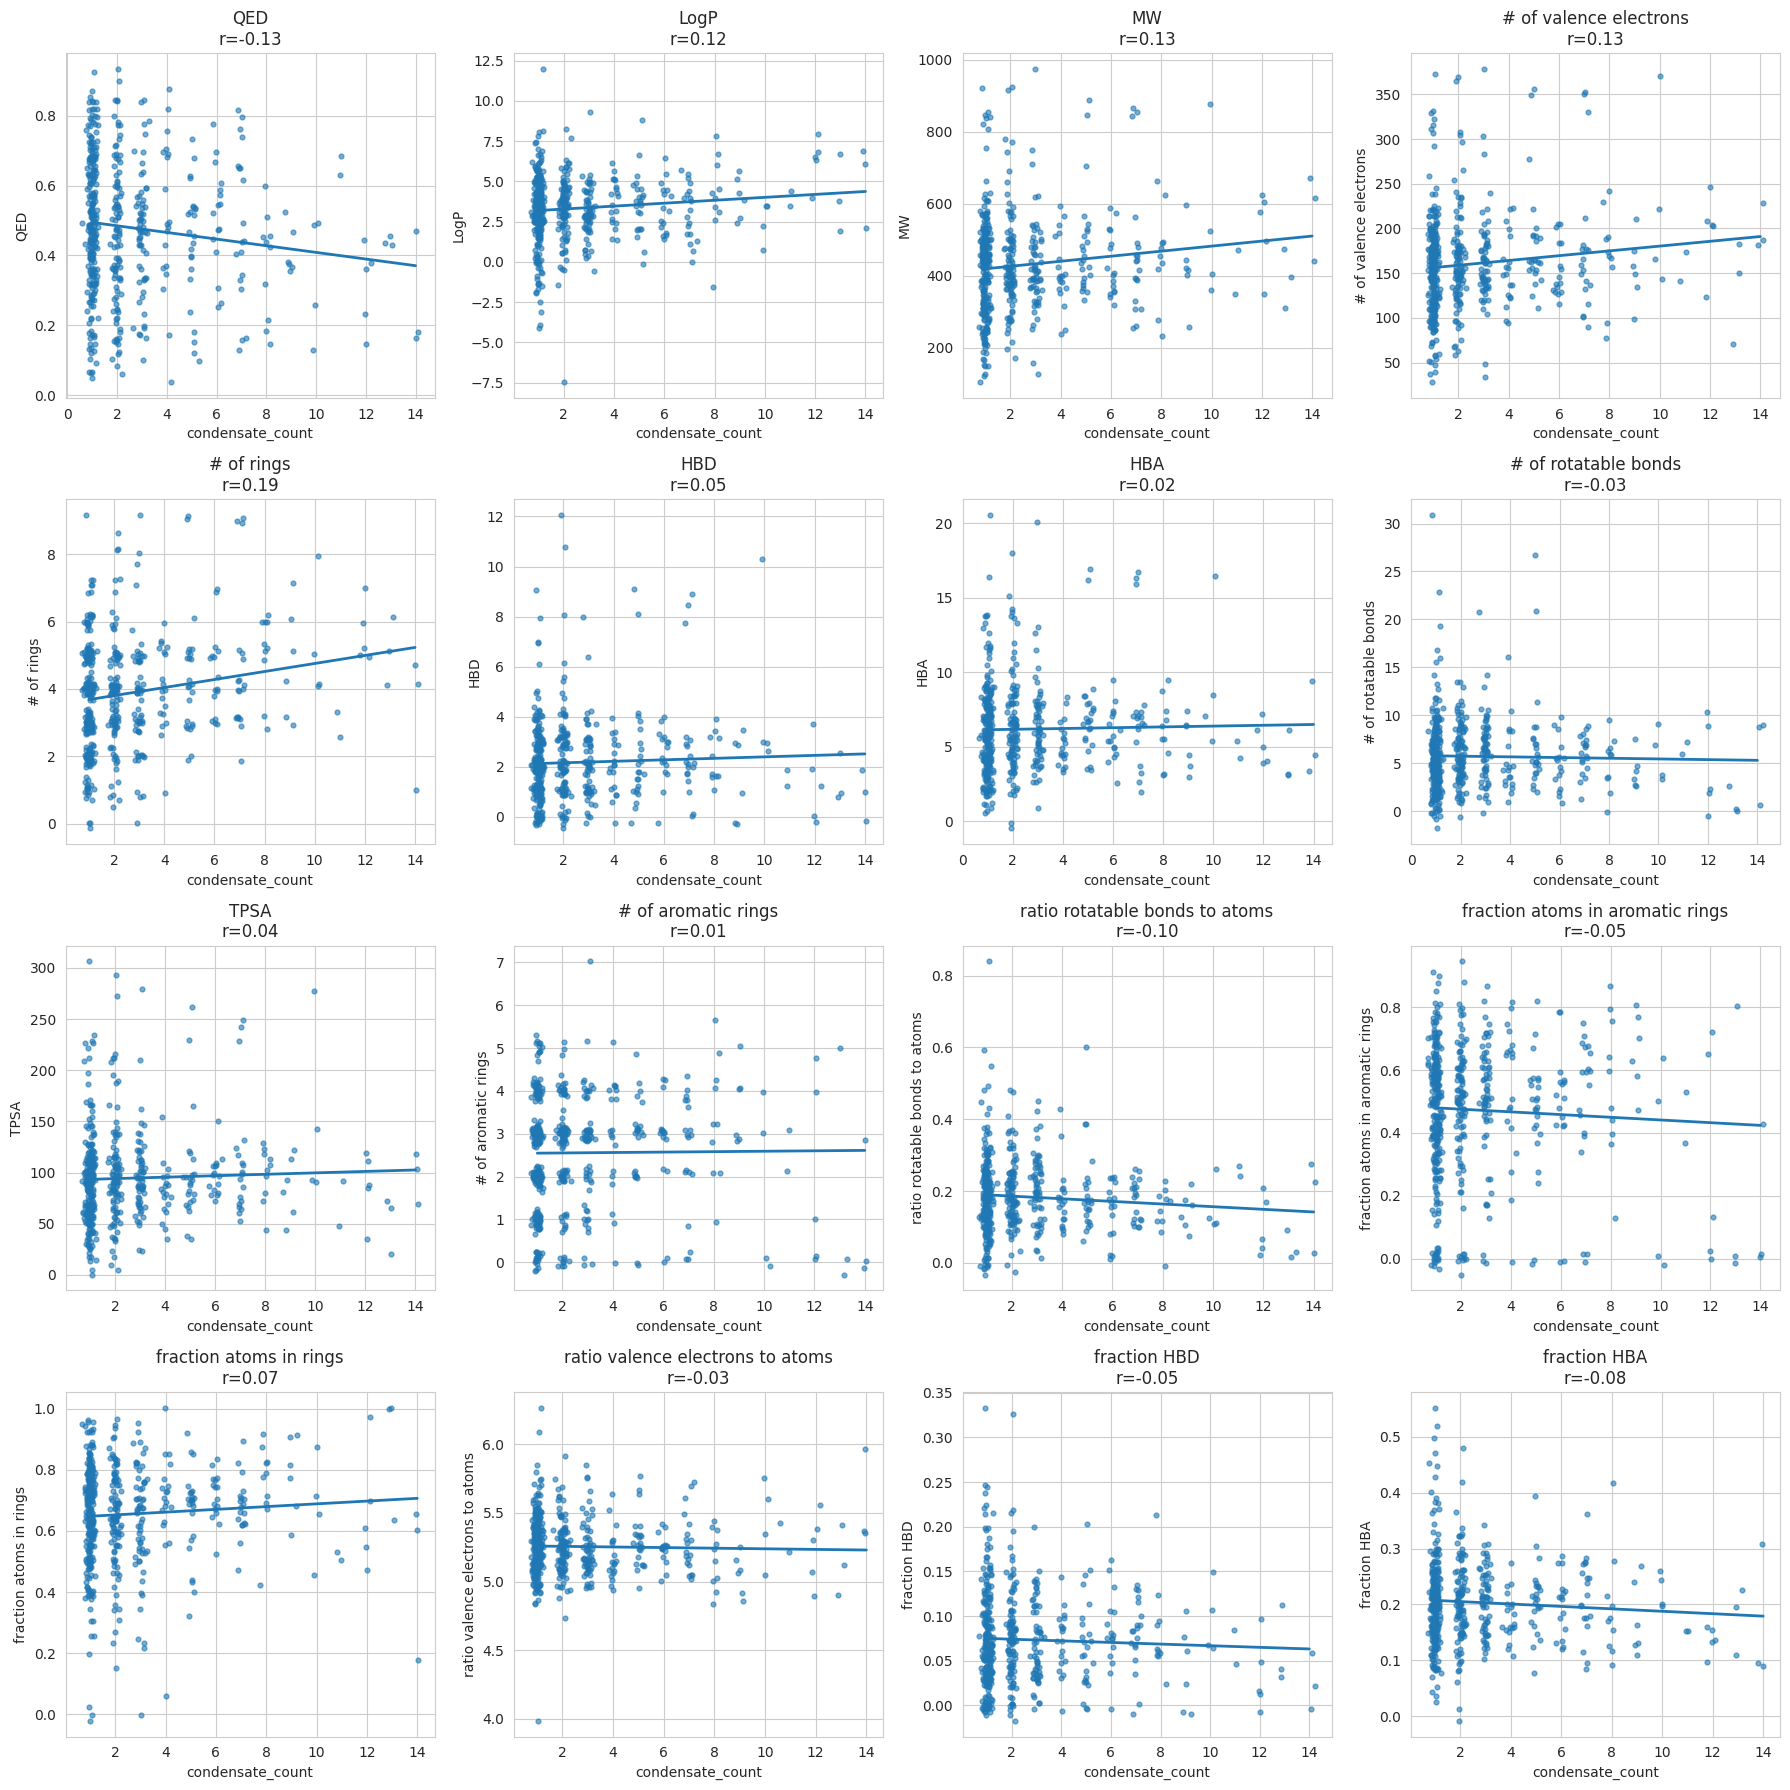

In [18]:
#Create scatter plots for all chemical descriptors
xcol = "condensate_count"
desc_cols = [
    "QED","LogP","MW","# of valence electrons","# of rings","HBD","HBA",
    "# of rotatable bonds","TPSA","# of aromatic rings",
    "ratio rotatable bonds to atoms","fraction atoms in aromatic rings",
    "fraction atoms in rings","ratio valence electrons to atoms",
    "fraction HBD","fraction HBA",
]

df = cmods_filtered_df

fig, axes = plt.subplots(4, 4, figsize=(18, 18))
axes = axes.ravel()

rng = np.random.default_rng(0)

# jitter settings
x_jitter_sd = 0.1
y_jitter_frac = 0.02

for ax, col in zip(axes, desc_cols):
    sub = df[[xcol, col]].dropna()
    if sub.empty:
        ax.set_title(f"{col}\n(no data)")
        ax.set_xlabel(xcol)
        ax.set_ylabel(col)
        continue

    x = sub[xcol].astype(float).to_numpy()
    y = sub[col].astype(float).to_numpy()

    # jitter x
    x_plot = np.clip(x + rng.normal(0, x_jitter_sd, size=x.shape), 0, None)

    # jitter y
    y_range = np.nanmax(y) - np.nanmin(y)
    y_sd = (y_jitter_frac * y_range) if np.isfinite(y_range) and y_range > 0 else 0.0
    y_plot = y + rng.normal(0, y_sd, size=y.shape)

    ax.scatter(x_plot, y_plot, s=12, alpha=0.6)

    # regression line
    r = np.nan
    if len(sub) >= 2 and np.nanmin(x) != np.nanmax(x):
        m, b = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 200)
        ax.plot(xs, m * xs + b, linewidth=2)
        r = np.corrcoef(x, y)[0, 1]
        ax.set_title(f"{col}\nr={r:.2f}")
    else:
        ax.set_title(f"{col}\n(n<2)")

    ax.set_xlabel(xcol)
    ax.set_ylabel(col)

for ax in axes[len(desc_cols):]:
    ax.axis("off")

fig.tight_layout()
#plt.savefig("./figures/correlation_by_condensates_modulated.png")
plt.show()
